In [18]:
import numpy as np
from scipy.signal._filter_design import butter 

# 1. Исходные параметры
cutoff_hz = 0.9      
samplingFreq = 360   
n = 2                

# 2. Расчет коэффициентов
b_sys, a_sys = butter(n, cutoff_hz, btype='high', analog=False, fs=samplingFreq)

b = b_sys
a = -a_sys

print("Filter coefficients b_i: " + str(b))
print("Filter coefficients a_i: " + str(a))

print("\nFormula: ")
print("y = {}*val + {}*prevFiltered + {}*prevUnFiltered + {}*prevprevFiltered + {}*prevprevUnfiltered".format(
    b[0], a[1], b[1], a[2], b[2]
))

Filter coefficients b_i: [ 0.98895425 -1.9779085   0.98895425]
Filter coefficients a_i: [-1.          1.97778648 -0.97803051]

Formula: 
y = 0.9889542480671397*val + 1.9777864837767636*prevFiltered + -1.9779084961342794*prevUnFiltered + -0.9780305084917958*prevprevFiltered + 0.9889542480671397*prevprevUnfiltered


Matplotlib is building the font cache; this may take a moment.


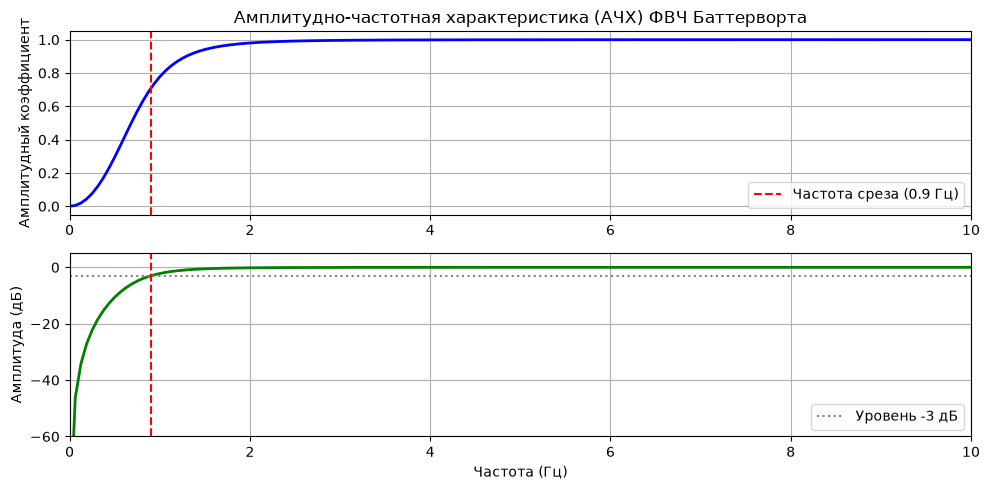

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Исходные параметры фильтра и коэффициенты из вашего вывода
samplingFreq = 250  # Частота дискретизации (Гц)

b = np.array([0.98413284, -1.96826569, 0.98413284])
# В исходном выводе a_i[0] = -1, а коэффициенты для формулы уже инвертированы.
# Для стандартной математической формулы H(z) возвращаем им исходные знаки:
a1_math = -1.96801391
a2_math = 0.96851747

# 2. Генерация сетки частот от 0 до частоты Найквиста (samplingFreq / 2)
# Возьмем 2000 точек для высокой точности графика
frequencies = np.linspace(0, samplingFreq / 2, 2000)

# Переводим частоты в радианы на отсчет (цифровая частота w)
w = 2 * np.pi * frequencies / samplingFreq

# Вычисляем комплексные экспоненты z^(-1) и z^(-2)
z1 = np.exp(-1j * w)
z2 = np.exp(-2j * w)

# 3. Расчет комплексного частотного отклика H(z)
numerator = b[0] + b[1] * z1 + b[2] * z2
denominator = 1 + a1_math * z1 + a2_math * z2
H = numerator / denominator

# Амплитудно-частотная характеристика (модуль комплексного числа)
magnitude = np.abs(H)

# Перевод амплитуды в децибелы (дБ) для стандартного отображения АЧХ
magnitude_db = 20 * np.log10(magnitude + 1e-10) # 1e-10 предотвращает логарифм нуля

# 4. Построение графика
plt.figure(figsize=(10, 5))

# Строим график в линейном масштабе (верхний)
plt.subplot(2, 1, 1)
plt.plot(frequencies, magnitude, 'b-', linewidth=2)
plt.axvline(0.9, color='r', linestyle='--', label='Частота среза (0.9 Гц)')
plt.title('Амплитудно-частотная характеристика (АЧХ) ФВЧ Баттерворта')
plt.ylabel('Амплитудный коэффициент')
plt.grid(True)
plt.legend()
plt.xlim(0, 10)  # Ограничим обзор до 10 Гц, чтобы детально рассмотреть срез

# Строим график в логарифмическом масштабе в дБ (нижний)
plt.subplot(2, 1, 2)
plt.plot(frequencies, magnitude_db, 'g-', linewidth=2)
plt.axvline(0.9, color='r', linestyle='--')
plt.axhline(-3, color='grey', linestyle=':', label='Уровень -3 дБ')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.xlim(0, 10)
plt.ylim(-60, 5) # Ограничим снизу для наглядности подавления

plt.tight_layout()
plt.show()


In [19]:
import numpy as np
from scipy.signal._filter_design import butter 

# 1. Исходные параметры
cutoff_hz = 35     
samplingFreq = 360  
n = 2                

# 2. Расчет коэффициентов
b_sys, a_sys = butter(n, cutoff_hz, btype='low', analog=False, fs=samplingFreq)

b = b_sys
a = -a_sys

print("Filter coefficients b_i: " + str(b))
print("Filter coefficients a_i: " + str(a))

print("\nFormula: ")
print("y = {}*val + {}*prevFiltered + {}*prevUnFiltered + {}*prevprevFiltered + {}*prevprevUnfiltered".format(
    b[0], a[1], b[1], a[2], b[2]
))

Filter coefficients b_i: [0.06433216 0.12866431 0.06433216]
Filter coefficients a_i: [-1.          1.16557175 -0.42290037]

Formula: 
y = 0.06433215577553819*val + 1.1655717469377458*prevFiltered + 0.12866431155107638*prevUnFiltered + -0.4229003700398986*prevprevFiltered + 0.06433215577553819*prevprevUnfiltered


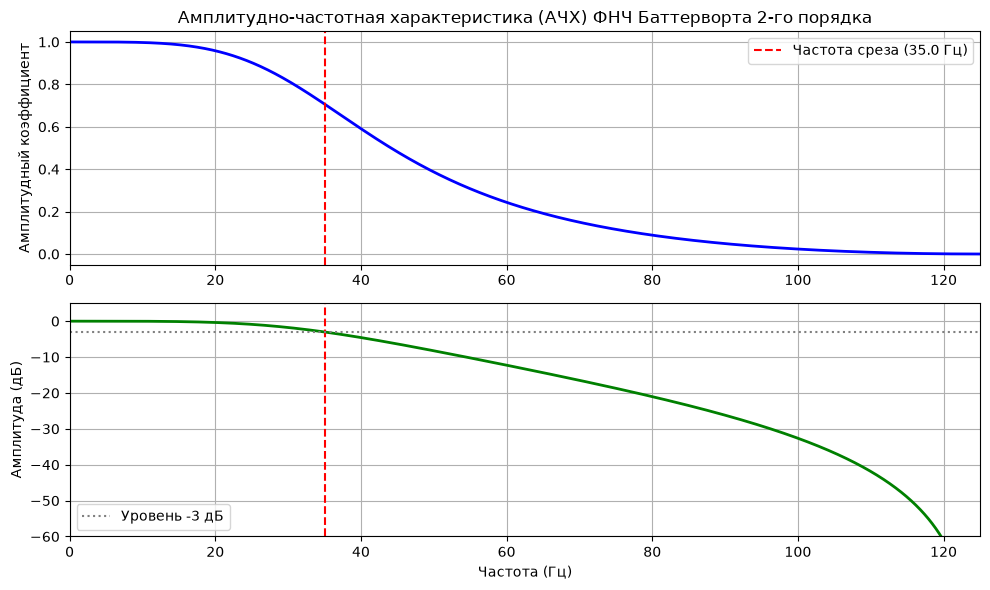

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Исходные параметры фильтра 
samplingFreq = 250  # Частота дискретизации (Гц)
cutoff_hz = 35.0    # Реальная частота среза ваших новых коэффициентов

b = np.array([0.11735104, 0.23470207, 0.11735104])

# Меняем знаки для математической формулы H(z).
# Если в разностном уравнении знаки были (+ 0.825... и - 0.294...), 
# то в H(z) они инвертируются относительно разностной схемы.
a1_math = -0.82523238
a2_math = 0.29463653  # Знак изменен с - на + для стабильности фильтра

# 2. Генерация сетки частот от 0 до частоты Найквиста (samplingFreq / 2 = 125 Гц)
frequencies = np.linspace(0, samplingFreq / 2, 2000)

# Переводим частоты в радианы на отсчет (цифровая частота w)
w = 2 * np.pi * frequencies / samplingFreq

# Вычисляем комплексные экспоненты z^(-1) и z^(-2)
z1 = np.exp(-1j * w)
z2 = np.exp(-2j * w)

# 3. Расчет комплексного частотного отклика H(z)
# ИСПРАВЛЕНО: числитель теперь корректно использует элементы массива b через индексы
numerator = b[0] + b[1] * z1 + b[2] * z2
denominator = 1 + a1_math * z1 + a2_math * z2
H = numerator / denominator

# Амплитудно-частотная характеристика (модуль комплексного числа)
magnitude = np.abs(H)

# Перевод амплитуды в децибелы (дБ)
magnitude_db = 20 * np.log10(magnitude + 1e-10)

# 4. Построение графика
plt.figure(figsize=(10, 6))

# Строим график в линейном масштабе (верхний)
plt.subplot(2, 1, 1)
plt.plot(frequencies, magnitude, 'b-', linewidth=2)
plt.axvline(cutoff_hz, color='r', linestyle='--', label=f'Частота среза ({cutoff_hz} Гц)')
plt.title('Амплитудно-частотная характеристика (АЧХ) ФНЧ Баттерворта 2-го порядка')
plt.ylabel('Амплитудный коэффициент')
plt.grid(True)
plt.legend()
plt.xlim(0, samplingFreq / 2)  # обзор до 125 Гц

# Строим график в логарифмическом масштабе в дБ (нижний)
plt.subplot(2, 1, 2)
plt.plot(frequencies, magnitude_db, 'g-', linewidth=2)
plt.axvline(cutoff_hz, color='r', linestyle='--')
plt.axhline(-3, color='grey', linestyle=':', label='Уровень -3 дБ')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.xlim(0, samplingFreq / 2) # обзор до 125 Гц
plt.ylim(-60, 5) 

plt.tight_layout()
plt.show()